## Navigation

1. [Loading Section](#loading-section)
2. [Data Validation Section](#data-validation-section)
3. [Data Preparation Section](#data-preparation-section)
4. [Scenario Modeling Section](#scenario-modeling-section)
5. [Visualizations Section](#visualizations-section)
6. [Key Findings](#key-findings)
7. [Business Recommendations](#business-recommendations)
8. [Conclusions](#conclusions)
9. [Exports Section](#exports-section)

## Loading Section

In [113]:
from pathlib import Path
from pprint import pprint

import pandas as pd
import matplotlib.pyplot as plt

In [114]:
root_path = Path.home() / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data"
capacity_planning_dir = root_path / "capacity"
raw_dir = root_path / "raw"

daily_capacity_file = "daily_capacity_requirements.csv"
capacity_requirements = pd.read_csv(capacity_planning_dir / daily_capacity_file, parse_dates=['date'])

historical_staffing_file = "staffing_plan.csv"
historical_staffing = pd.read_csv(raw_dir / historical_staffing_file, parse_dates=['date'])

[Back to Top](#navigation)

## Data Validation section

In [115]:
pprint(capacity_requirements.info())
print("\n")
pprint(capacity_requirements.describe())
print("\n")
print("Missing values: ")
pprint(capacity_requirements.isna().sum())
print("\nDuplicate values: ")
pprint(capacity_requirements.duplicated().sum())
print("\n")
pprint(f"First date: {capacity_requirements['date'].min()}")
pprint(f"Last date: {capacity_requirements['date'].max()}")

<class 'pandas.DataFrame'>
RangeIndex: 365 entries, 0 to 364
Data columns (total 11 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             365 non-null    datetime64[us]
 1   dow_num                          365 non-null    int64         
 2   day_of_week                      365 non-null    str           
 3   month                            365 non-null    str           
 4   forecast                         365 non-null    float64       
 5   aht_assumption                   365 non-null    float64       
 6   shrinkage_assumption             365 non-null    float64       
 7   workload_hrs                     365 non-null    float64       
 8   required_fte_raw                 365 non-null    float64       
 9   required_fte_shrinkage_adjusted  365 non-null    float64       
 10  fte_delta                        365 non-null    float64       
dtypes: d

In [116]:
pprint(historical_staffing.info())
print("\n")
pprint(historical_staffing.describe())
print("\n")
print("Missing values: ")
pprint(historical_staffing.isna().sum())
print("\nDuplicate values: ")
pprint(historical_staffing.duplicated().sum())
print("\n")
pprint(f"First date: {historical_staffing['date'].min()}")
pprint(f"Last date: {historical_staffing['date'].max()}")

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           731 non-null    datetime64[us]
 1   scheduled_fte  731 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 11.6 KB
None


                      date  scheduled_fte
count                  731     731.000000
mean   2024-12-31 00:00:00      70.362517
min    2024-01-01 00:00:00      27.000000
25%    2024-07-01 12:00:00      54.000000
50%    2024-12-31 00:00:00      72.000000
75%    2025-07-01 12:00:00      84.000000
max    2025-12-31 00:00:00     141.000000
std                    NaN      21.529557


Missing values: 
date             0
scheduled_fte    0
dtype: int64

Duplicate values: 
np.int64(0)


'First date: 2024-01-01 00:00:00'
'Last date: 2025-12-31 00:00:00'


[Back to Top](#navigation)

## Data Preparation Section

In [117]:
start_dt = pd.to_datetime('2024-01-01')
end_dt = pd.to_datetime('2026-12-31')
calendar_df = (
    pd.date_range(start=start_dt, end=end_dt)
    .to_frame(index=False, name="date")
    .assign(
        year=lambda df: df['date'].dt.year,
        month_num=lambda df: df['date'].dt.month,
        month_name=lambda df: df['date'].dt.month_name(),
        year_month=lambda df: df['date'].dt.strftime('%Y-%B'),
        week_of_year=lambda df: df['date'].dt.isocalendar().week,
    )
)
pprint(calendar_df.head())
print("\n")
pprint(calendar_df['date'].min())
print("\n")
pprint(calendar_df['date'].max())

        date  year  month_num month_name    year_month  week_of_year
0 2024-01-01  2024          1    January  2024-January             1
1 2024-01-02  2024          1    January  2024-January             1
2 2024-01-03  2024          1    January  2024-January             1
3 2024-01-04  2024          1    January  2024-January             1
4 2024-01-05  2024          1    January  2024-January             1


Timestamp('2024-01-01 00:00:00')


Timestamp('2026-12-31 00:00:00')


In [118]:
forecasted_data = pd.merge(
    calendar_df,
    capacity_requirements,
    on='date'
)
pprint(forecasted_data.head())

        date  year  month_num month_name    year_month  week_of_year  dow_num  \
0 2026-01-01  2026          1    January  2026-January             1        3   
1 2026-01-02  2026          1    January  2026-January             1        4   
2 2026-01-03  2026          1    January  2026-January             1        5   
3 2026-01-04  2026          1    January  2026-January             1        6   
4 2026-01-05  2026          1    January  2026-January             2        0   

  day_of_week    month  forecast  aht_assumption  shrinkage_assumption  \
0    Thursday  January   3518.03          479.56                0.3016   
1      Friday  January   3190.71          479.56                0.3016   
2    Saturday  January   2457.71          479.56                0.3016   
3      Sunday  January   1725.57          479.56                0.3016   
4      Monday  January   4303.93          479.56                0.3016   

   workload_hrs  required_fte_raw  required_fte_shrinkage_adjusted  

In [119]:
historical_staffing = pd.merge(
    calendar_df,
    historical_staffing,
    on='date'
)
pprint(historical_staffing.head())

year_start = pd.to_datetime('2025-01-01')
year_end = pd.to_datetime('2025-12-31')
staffing_2025 = historical_staffing.loc[
    historical_staffing['date'].between(year_start, year_end)
]
pprint(staffing_2025.head())

        date  year  month_num month_name    year_month  week_of_year  \
0 2024-01-01  2024          1    January  2024-January             1   
1 2024-01-02  2024          1    January  2024-January             1   
2 2024-01-03  2024          1    January  2024-January             1   
3 2024-01-04  2024          1    January  2024-January             1   
4 2024-01-05  2024          1    January  2024-January             1   

   scheduled_fte  
0             79  
1             93  
2             58  
3             66  
4             58  
          date  year  month_num month_name    year_month  week_of_year  \
366 2025-01-01  2025          1    January  2025-January             1   
367 2025-01-02  2025          1    January  2025-January             1   
368 2025-01-03  2025          1    January  2025-January             1   
369 2025-01-04  2025          1    January  2025-January             1   
370 2025-01-05  2025          1    January  2025-January             1   

     sch

In [120]:
annual_summary = historical_staffing.groupby('year', as_index=False).agg(
    total_fte=('scheduled_fte', 'sum'),
    average_fte=('scheduled_fte', lambda s: s.mean().round(2)),
    max_fte=('scheduled_fte', 'max'),
    min_fte=('scheduled_fte', 'min'),
    median_fte=('scheduled_fte', 'median'),
)
pprint(annual_summary.head())

   year  total_fte  average_fte  max_fte  min_fte  median_fte
0  2024      25358        69.28      126       28        70.0
1  2025      26077        71.44      141       27        74.0


In [121]:
monthly_summary_2025 = staffing_2025.groupby('month_num', as_index=False).agg(
    month=('month_name', 'first'),
    total_fte=('scheduled_fte', 'sum'),
    average_fte=('scheduled_fte', lambda s: s.mean().round(2)),
    max_fte=('scheduled_fte', 'max'),
    min_fte=('scheduled_fte', 'min'),
    median_fte=('scheduled_fte', 'median'),
)
pprint(monthly_summary_2025.head(13))

    month_num      month  total_fte  average_fte  max_fte  min_fte  median_fte
0           1    January       2038        65.74       88       33        71.0
1           2   February       1815        64.82       96       30        71.5
2           3      March       2014        64.97       96       34        69.0
3           4      April       2180        72.67      105       39        77.0
4           5        May       2326        75.03      113       35        78.0
5           6       June       2277        75.90      111       37        78.0
6           7       July       1907        61.52       93       28        65.0
7           8     August       1811        58.42       94       27        58.0
8           9  September       2162        72.07       99       34        74.5
9          10    October       2347        75.71      117       33        76.0
10         11   November       2298        76.60      124       33        75.5
11         12   December       2902        93.61    

In [122]:
week_of_year_summary_2025 = staffing_2025.groupby('week_of_year', as_index=False).agg(
    total_fte=('scheduled_fte', 'sum'),
    average_fte=('scheduled_fte', lambda s: s.mean().round(2)),
    max_fte=('scheduled_fte', 'max'),
    min_fte=('scheduled_fte', 'min'),
    median_fte=('scheduled_fte', 'median'),
)
pprint(week_of_year_summary_2025.head())
print("\n")
pprint(f"Total rows: {len(week_of_year_summary_2025)}")

   week_of_year  total_fte  average_fte  max_fte  min_fte  median_fte
0             1        608        76.00      115       33        76.5
1             2        469        67.00       86       36        71.0
2             3        470        67.14       87       34        69.0
3             4        461        65.86       88       39        71.0
4             5        438        62.57       78       42        70.0


'Total rows: 52'


[Back to Top](#navigation)

## Scenario modeling section

| Scenario          | Assumption                       |
| ----------------- | -------------------------------- |
| Baseline          | Historical average staffing      |
| Hiring            | Workforce increased by 15%       |
| Attrition         | Workforce reduced by 15%         |


In [123]:
staffing_assumptions = pd.DataFrame({
    'scenario': ['baseline', 'hiring', 'attrition'],
    'multiplier': [1.0, 1.15, 0.85]
})
pprint(staffing_assumptions.head())

    scenario  multiplier
0   baseline        1.00
1     hiring        1.15
2  attrition        0.85


In [124]:
staffing_scenario = (
    pd.merge(
        week_of_year_summary_2025[['week_of_year', 'average_fte']],
        staffing_assumptions,
        how='cross'
    ).assign(
        fte_availability=lambda df: (df['average_fte'] * df['multiplier']).round(2)
    ).drop(
        columns=['average_fte', 'multiplier']
    )
)
print("Staffing Scenario: ")
pprint(staffing_scenario.head())

final_dataset = pd.merge(
    forecasted_data,
    staffing_scenario,
    on='week_of_year'
)
print("Final Dataset: ")
pprint(final_dataset.head())

Staffing Scenario: 
   week_of_year   scenario  fte_availability
0             1   baseline             76.00
1             1     hiring             87.40
2             1  attrition             64.60
3             2   baseline             67.00
4             2     hiring             77.05
Final Dataset: 
        date  year  month_num month_name    year_month  week_of_year  dow_num  \
0 2026-01-01  2026          1    January  2026-January             1        3   
1 2026-01-01  2026          1    January  2026-January             1        3   
2 2026-01-01  2026          1    January  2026-January             1        3   
3 2026-01-02  2026          1    January  2026-January             1        4   
4 2026-01-02  2026          1    January  2026-January             1        4   

  day_of_week    month  forecast  aht_assumption  shrinkage_assumption  \
0    Thursday  January   3518.03          479.56                0.3016   
1    Thursday  January   3518.03          479.56           

In [125]:
def categorize(df: pd.DataFrame):
    return pd.cut(
            df['coverage_pct'],
            bins=[-float('inf'), 75, 85, 95, 105, float('inf')],
            labels=['Critical', 'High Risk', 'Moderate Risk', 'Low Risk', 'Surplus'],
            right=False
        )

analysis_df = final_dataset.assign(
    staffing_gap=lambda df: (
        df["fte_availability"] - df["required_fte_shrinkage_adjusted"]
    ).round(2),
    coverage_pct=lambda df: (
        (df["fte_availability"] / df["required_fte_shrinkage_adjusted"]) * 100
    ).round(2),
    risk_level=categorize
)
pprint(analysis_df.head())

        date  year  month_num month_name    year_month  week_of_year  dow_num  \
0 2026-01-01  2026          1    January  2026-January             1        3   
1 2026-01-01  2026          1    January  2026-January             1        3   
2 2026-01-01  2026          1    January  2026-January             1        3   
3 2026-01-02  2026          1    January  2026-January             1        4   
4 2026-01-02  2026          1    January  2026-January             1        4   

  day_of_week    month  forecast  ...  shrinkage_assumption  workload_hrs  \
0    Thursday  January   3518.03  ...                0.3016        468.64   
1    Thursday  January   3518.03  ...                0.3016        468.64   
2    Thursday  January   3518.03  ...                0.3016        468.64   
3      Friday  January   3190.71  ...                0.3016        425.04   
4      Friday  January   3190.71  ...                0.3016        425.04   

   required_fte_raw  required_fte_shrinkage_adjust

In [126]:
result_df = analysis_df[[
    'date',
    'year',
    'month_num',
    'month_name',
    'year_month',
    'week_of_year',
    'dow_num',
    'day_of_week',
    'scenario',
    'fte_availability',
    'required_fte_shrinkage_adjusted',
    'staffing_gap',
    'coverage_pct',
    'risk_level'
]].rename(
    columns={
        'fte_availability': 'available_fte',
        'required_fte_shrinkage_adjusted': 'required_fte'
    }
)
pprint(result_df.head())

def rounded_mean(series: pd.Series):
    return series.mean().round(2)


result_summarized = result_df.groupby('scenario', as_index=False).agg(
    avg_available_fte=('available_fte', rounded_mean),
    avg_required_fte=('required_fte', rounded_mean),
    avg_gap=('staffing_gap', rounded_mean),
    min_gap=('staffing_gap', 'min'),
    max_gap=('staffing_gap', 'max'),
    avg_coverage_pct=('coverage_pct', rounded_mean),
    min_coverage_pct=('coverage_pct', 'min'),
    max_coverage_pct=('coverage_pct', 'max'),
    surplus_days=('risk_level', lambda s: (s == 'Surplus').sum()),
    low_risk_days=('risk_level', lambda s: (s == 'Low Risk').sum()),
    moderate_risk_days=('risk_level', lambda s: (s == 'Moderate Risk').sum()),
    high_risk_days=('risk_level', lambda s: (s == 'High Risk').sum()),
    critical_risk_days=('risk_level', lambda s: (s == 'Critical').sum())
)
pprint(result_summarized.head())

        date  year  month_num month_name    year_month  week_of_year  dow_num  \
0 2026-01-01  2026          1    January  2026-January             1        3   
1 2026-01-01  2026          1    January  2026-January             1        3   
2 2026-01-01  2026          1    January  2026-January             1        3   
3 2026-01-02  2026          1    January  2026-January             1        4   
4 2026-01-02  2026          1    January  2026-January             1        4   

  day_of_week   scenario  available_fte  required_fte  staffing_gap  \
0    Thursday   baseline           76.0         83.88         -7.88   
1    Thursday     hiring           87.4         83.88          3.52   
2    Thursday  attrition           64.6         83.88        -19.28   
3      Friday   baseline           76.0         76.07         -0.07   
4      Friday     hiring           87.4         76.07         11.33   

   coverage_pct     risk_level  
0         90.61  Moderate Risk  
1        104.20     

[Back to Top](#navigation)

## Visualizations Section

In [127]:
title_font={
    'fontsize': 10,
    'fontweight': 'bold'
}
label_font={
    'fontweight': 'bold'
}

baseline_scenario = result_df.loc[result_df['scenario'] == 'baseline']
hiring_scenario = result_df.loc[result_df['scenario'] == 'hiring']
attrition_scenario = result_df.loc[result_df['scenario'] == 'attrition']

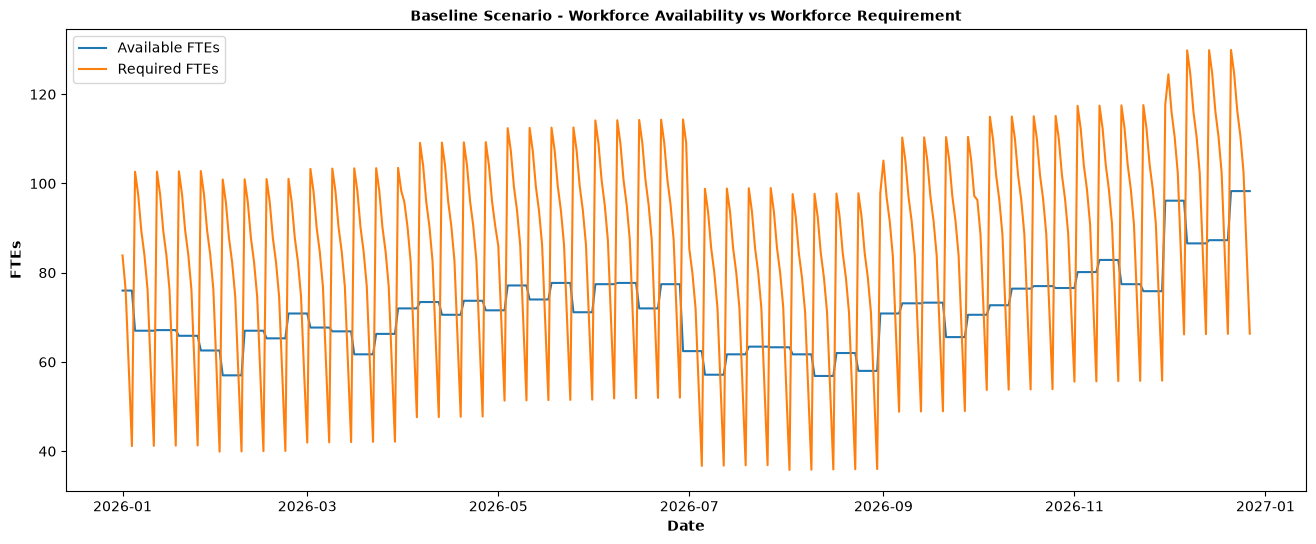

In [128]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    baseline_scenario['date'], 
    baseline_scenario['available_fte'],
    label='Available FTEs'
)
ax.plot(
    baseline_scenario['date'], 
    baseline_scenario['required_fte'],
    label='Required FTEs'
)
ax.set_title('Baseline Scenario - Workforce Availability vs Workforce Requirement', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.set_ylabel('FTEs', fontdict=label_font)
ax.legend()
plt.show()

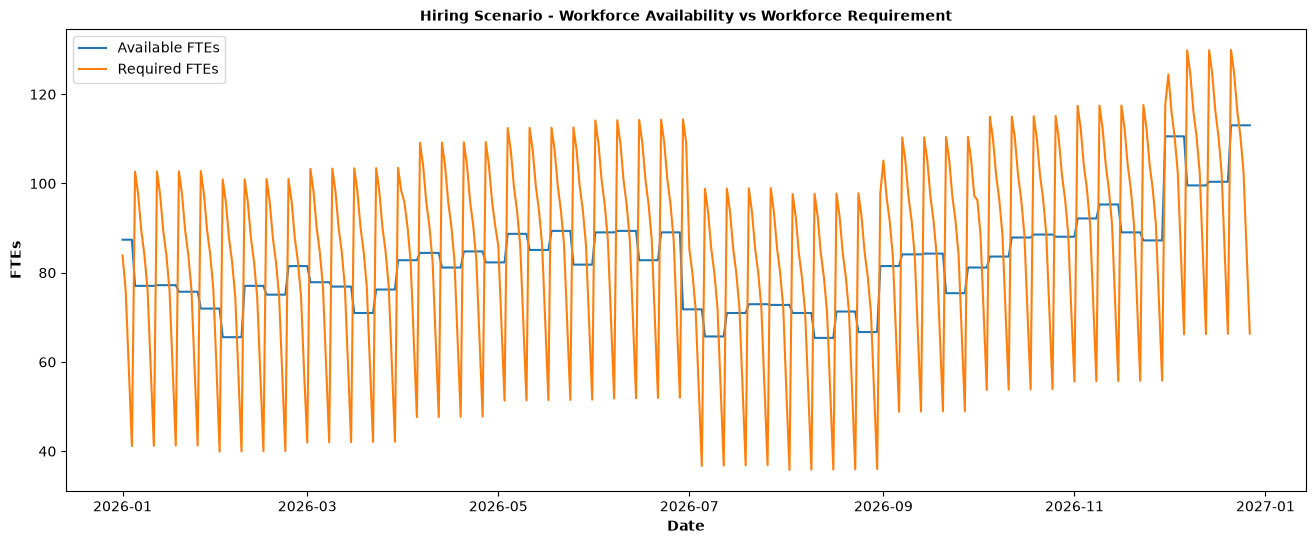

In [129]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    hiring_scenario['date'], 
    hiring_scenario['available_fte'],
    label='Available FTEs'
)
ax.plot(
    hiring_scenario['date'], 
    hiring_scenario['required_fte'],
    label='Required FTEs'
)
ax.set_title('Hiring Scenario - Workforce Availability vs Workforce Requirement', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.set_ylabel('FTEs', fontdict=label_font)
ax.legend()
plt.show()

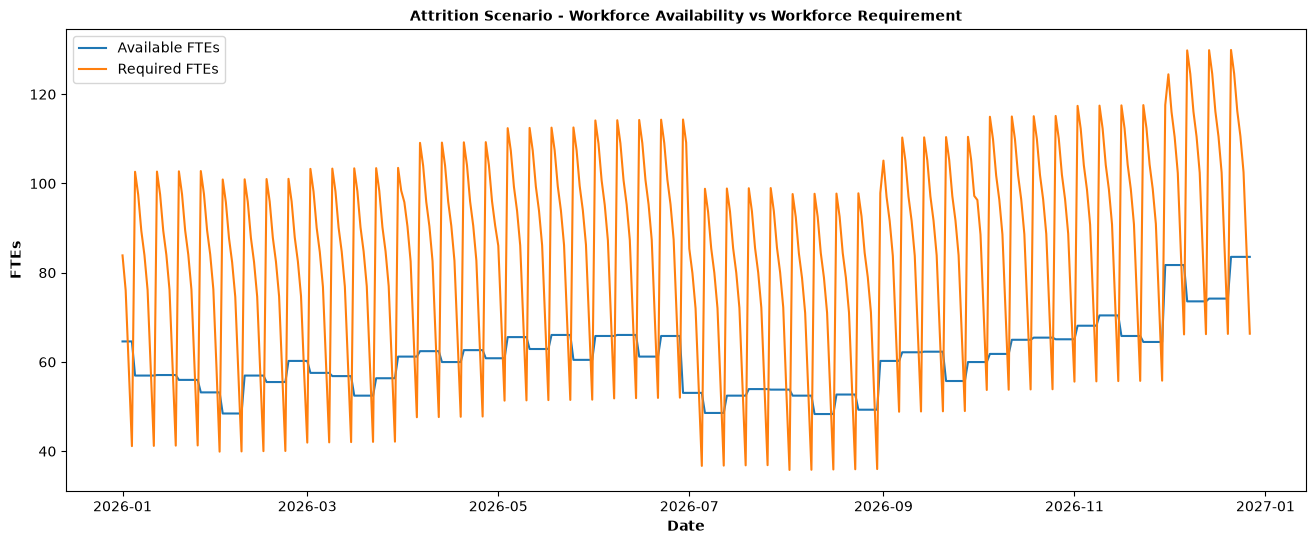

In [130]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    attrition_scenario['date'], 
    attrition_scenario['available_fte'],
    label='Available FTEs'
)
ax.plot(
    attrition_scenario['date'], 
    attrition_scenario['required_fte'],
    label='Required FTEs'
)
ax.set_title('Attrition Scenario - Workforce Availability vs Workforce Requirement', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.set_ylabel('FTEs', fontdict=label_font)
ax.legend()
plt.show()

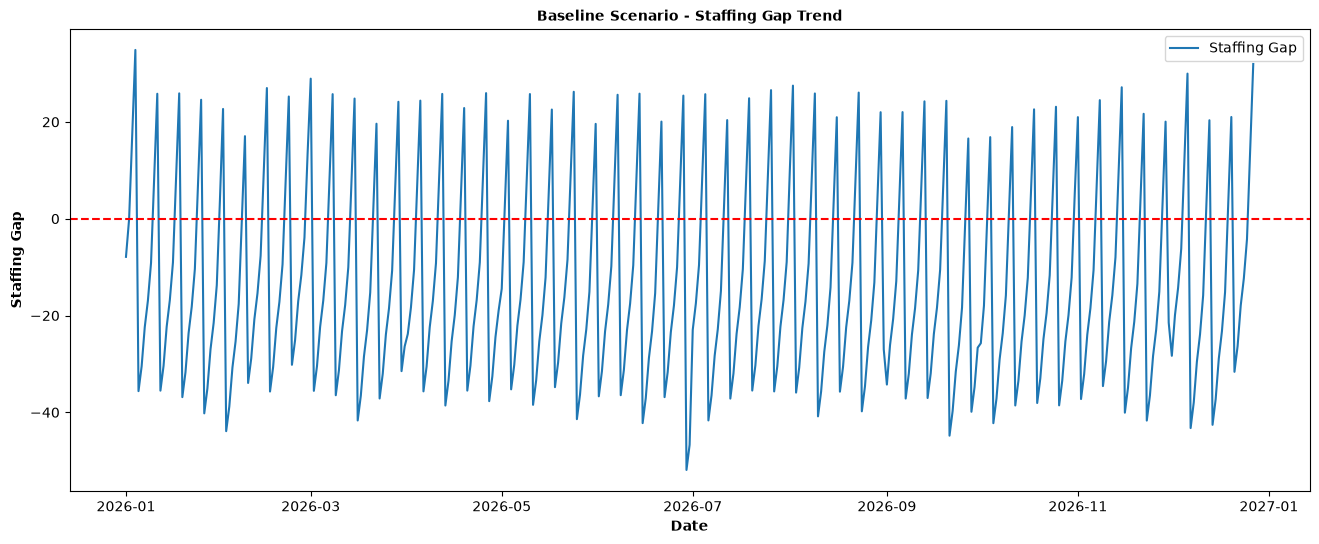

In [131]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    baseline_scenario['date'], 
    baseline_scenario['staffing_gap'],
    label='Staffing Gap'
)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Baseline Scenario - Staffing Gap Trend', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.set_ylabel('Staffing Gap', fontdict=label_font)
ax.legend()
plt.show()

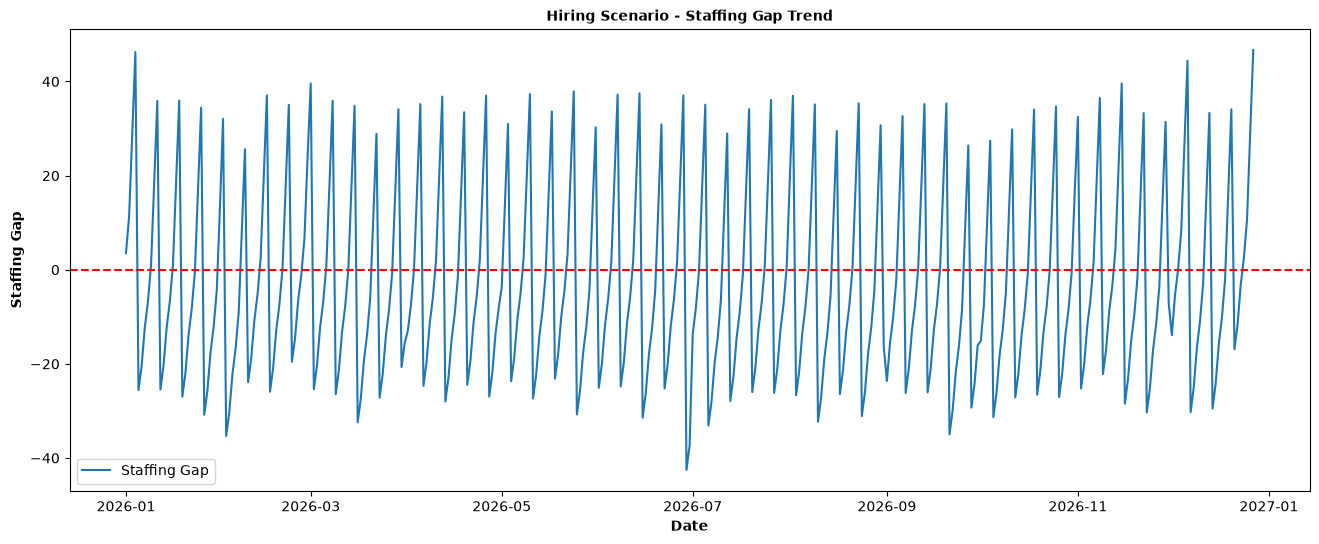

In [132]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    hiring_scenario['date'], 
    hiring_scenario['staffing_gap'],
    label='Staffing Gap'
)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Hiring Scenario - Staffing Gap Trend', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.set_ylabel('Staffing Gap', fontdict=label_font)
ax.legend()
plt.show()

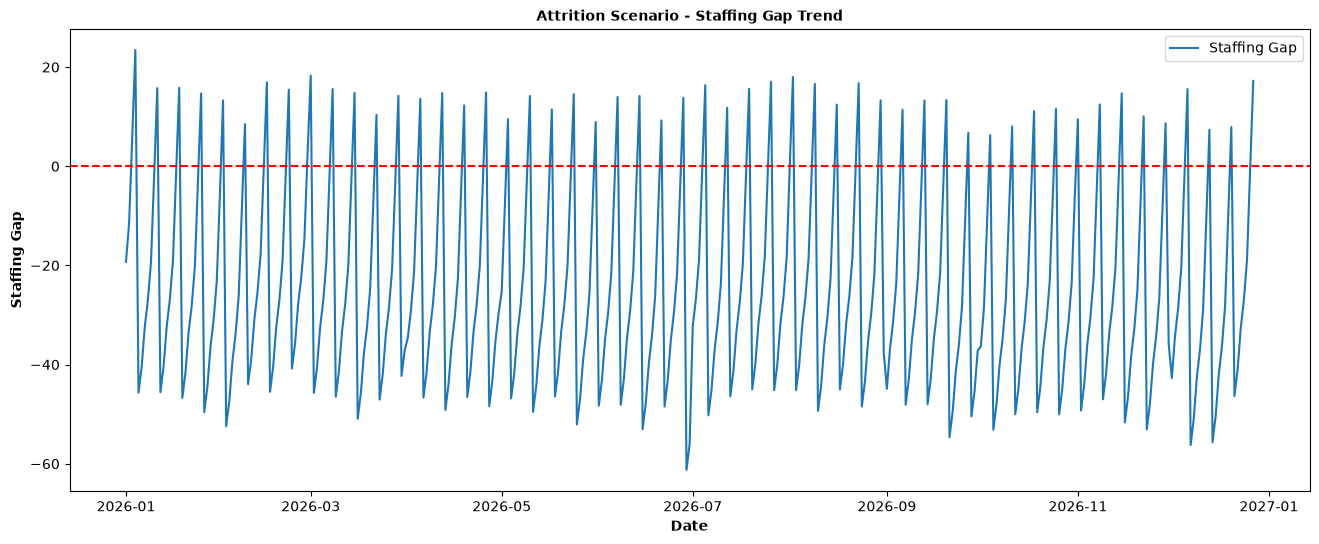

In [133]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    attrition_scenario['date'], 
    attrition_scenario['staffing_gap'],
    label='Staffing Gap'
)
ax.axhline(y=0, color='r', linestyle='--')
ax.set_title('Attrition Scenario - Staffing Gap Trend', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.set_ylabel('Staffing Gap', fontdict=label_font)
ax.legend()
plt.show()

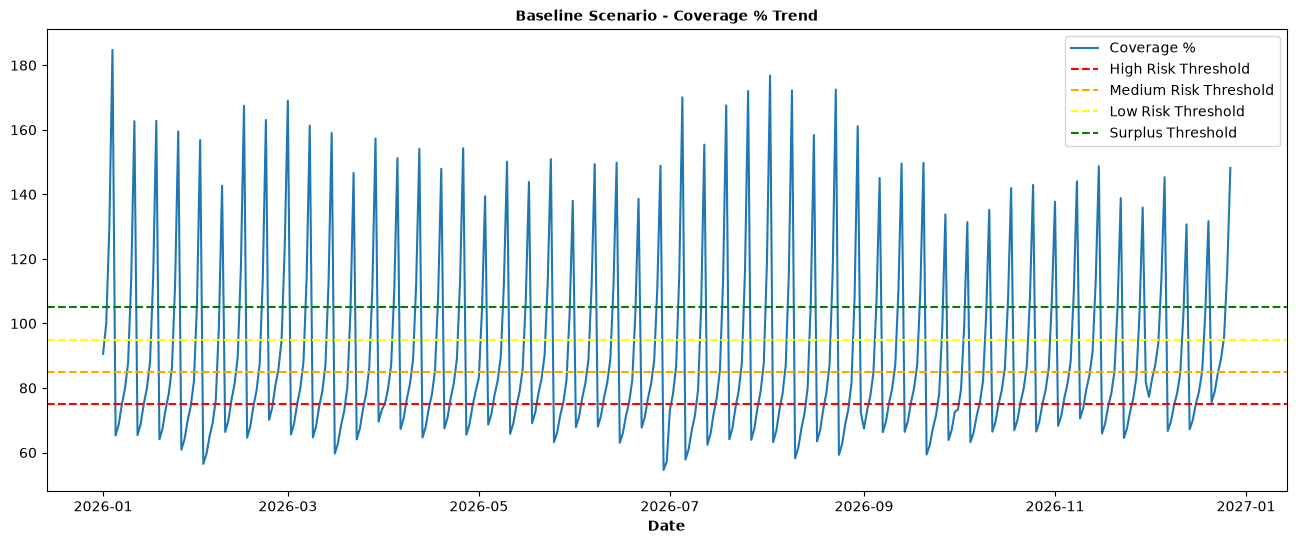

In [140]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    baseline_scenario['date'], 
    baseline_scenario['coverage_pct'],
    label='Coverage %'
)
ax.axhline(y=75, color='red', linestyle='--', label='High Risk Threshold')
ax.axhline(y=85, color='orange', linestyle='--', label='Medium Risk Threshold')
ax.axhline(y=95, color='yellow', linestyle='--', label='Low Risk Threshold')
ax.axhline(y=105, color='green', linestyle='--', label='Surplus Threshold')
ax.set_title('Baseline Scenario - Coverage % Trend', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.legend()
plt.show()

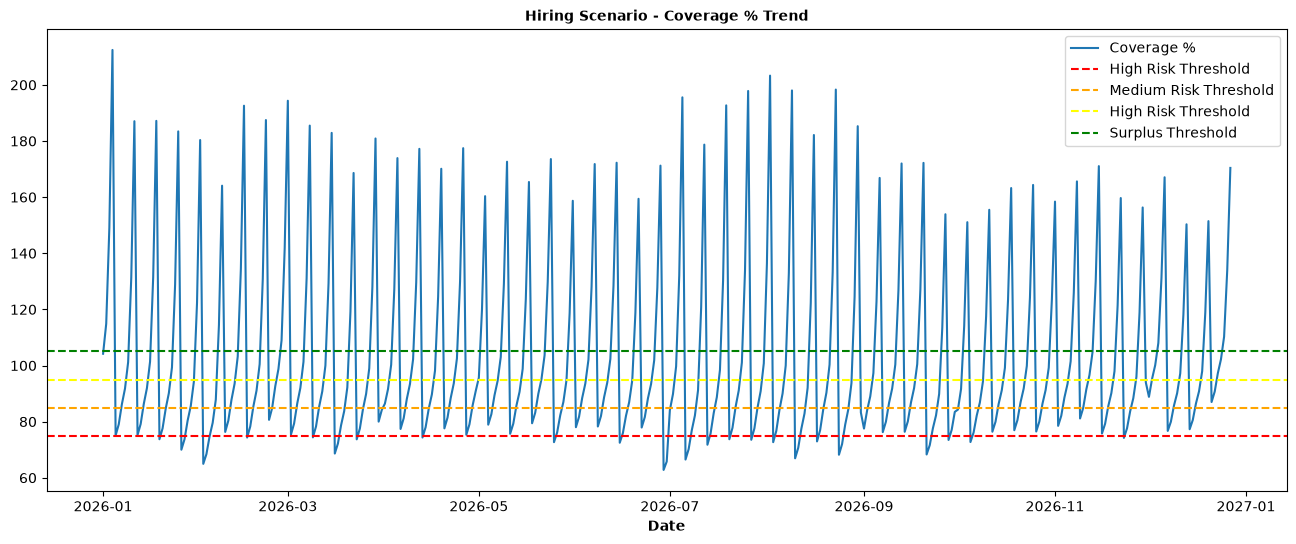

In [135]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    hiring_scenario['date'], 
    hiring_scenario['coverage_pct'],
    label='Coverage %'
)
ax.axhline(y=75, color='red', linestyle='--', label='High Risk Threshold')
ax.axhline(y=85, color='orange', linestyle='--', label='Medium Risk Threshold')
ax.axhline(y=95, color='yellow', linestyle='--', label='High Risk Threshold')
ax.axhline(y=105, color='green', linestyle='--', label='Surplus Threshold')
ax.set_title('Hiring Scenario - Coverage % Trend', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.legend()
plt.show()

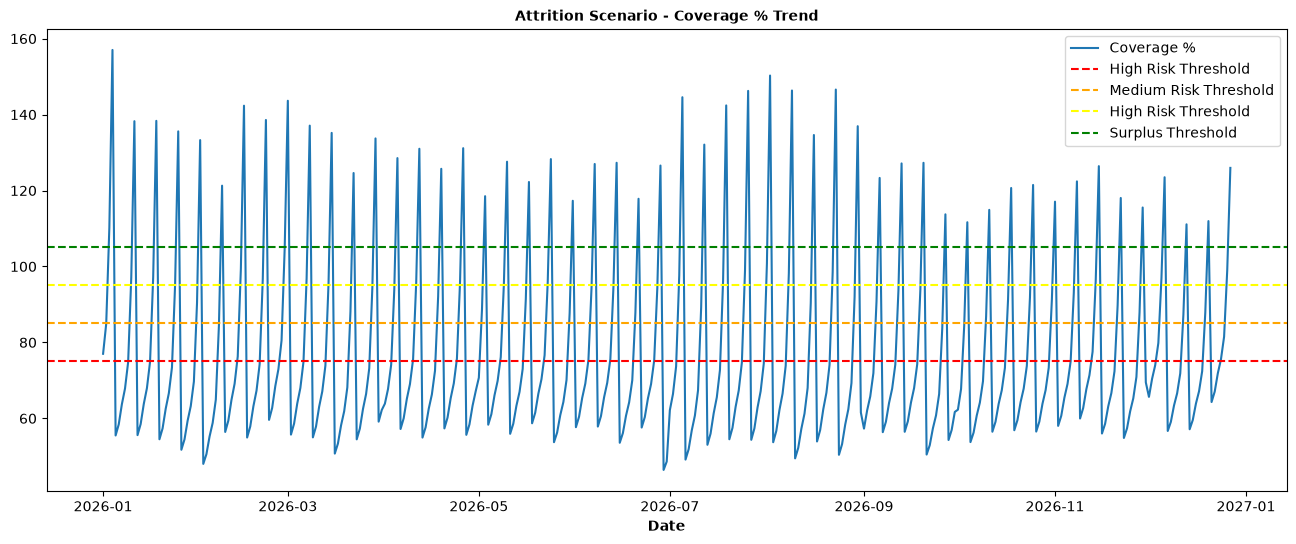

In [136]:
fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(
    attrition_scenario['date'], 
    attrition_scenario['coverage_pct'],
    label='Coverage %'
)
ax.axhline(y=75, color='red', linestyle='--', label='High Risk Threshold')
ax.axhline(y=85, color='orange', linestyle='--', label='Medium Risk Threshold')
ax.axhline(y=95, color='yellow', linestyle='--', label='High Risk Threshold')
ax.axhline(y=105, color='green', linestyle='--', label='Surplus Threshold')
ax.set_title('Attrition Scenario - Coverage % Trend', fontdict=title_font)
ax.set_xlabel('Date', fontdict=label_font)
ax.legend()
plt.show()

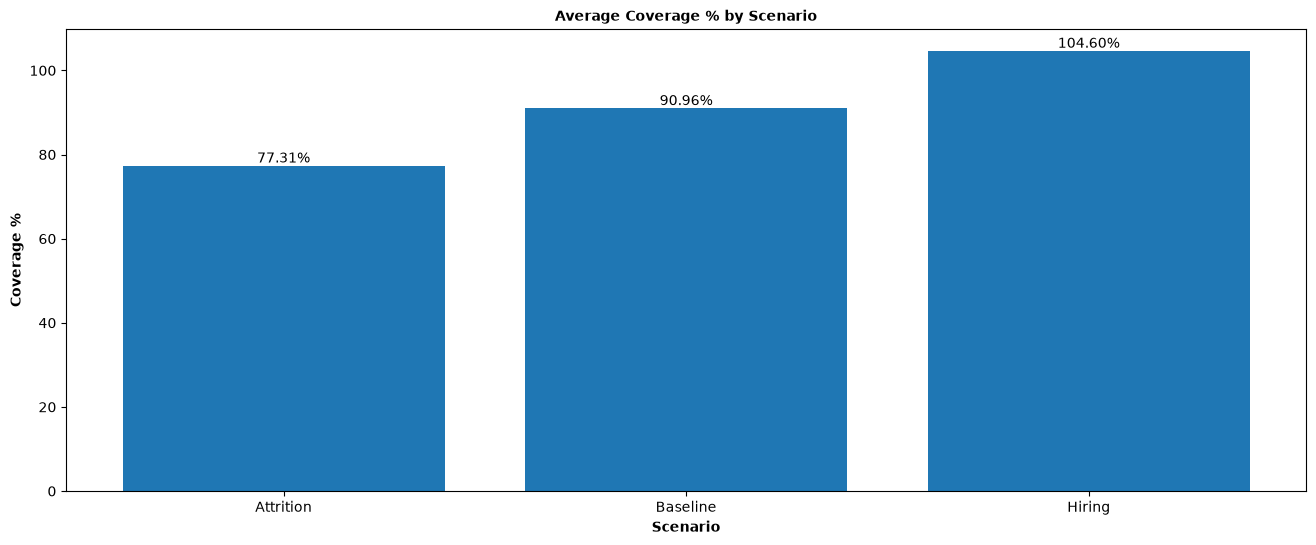

In [137]:
result_summarized['scenario'] = result_summarized['scenario'].str.capitalize()
fig, ax = plt.subplots(figsize=(16, 6))

bars = ax.bar(
    result_summarized['scenario'],
    result_summarized['avg_coverage_pct'],
)
ax.bar_label(bars, fmt='%.2f%%')
ax.set_title('Average Coverage % by Scenario', fontdict=title_font)
ax.set_xlabel('Scenario', fontdict=label_font)
ax.set_ylabel('Coverage %', fontdict=label_font)
plt.show()

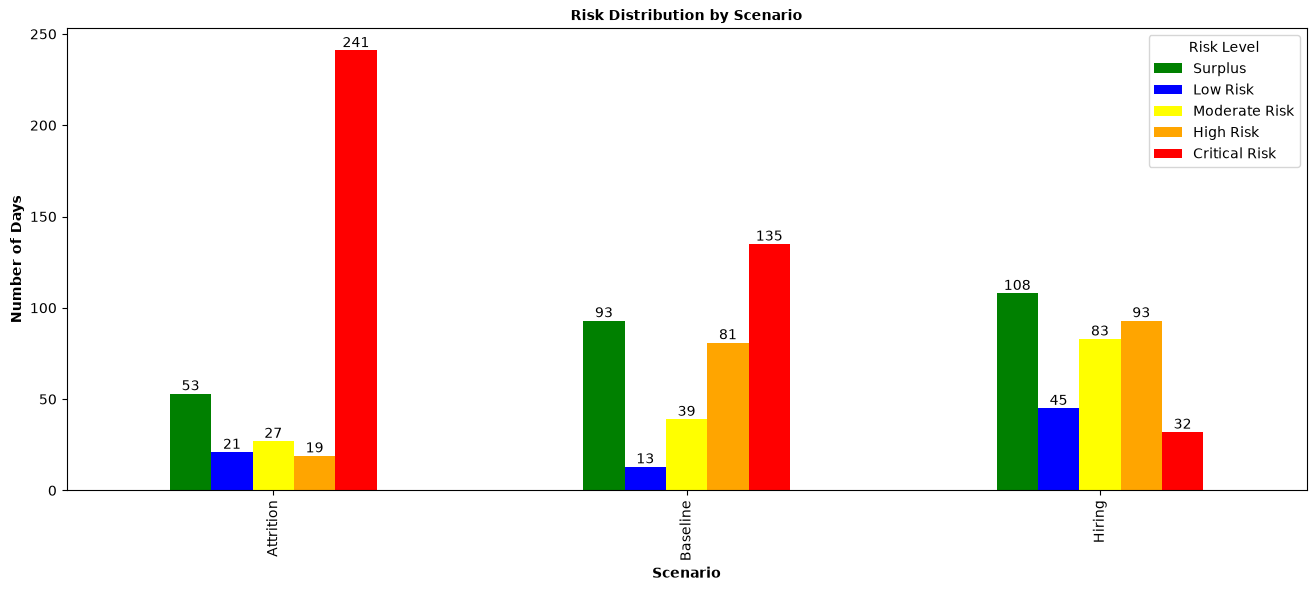

In [138]:
risk_distribution = result_summarized[['scenario', 'surplus_days', 'low_risk_days', 'moderate_risk_days', 'high_risk_days', 'critical_risk_days']]
color_map = {
    'surplus_days': 'green',
    'low_risk_days': 'blue',
    'moderate_risk_days': 'yellow',
    'high_risk_days': 'orange',
    'critical_risk_days': 'red'
}
colors = [color_map[c] for c in risk_distribution.columns if c != 'scenario']
fig, ax = plt.subplots(figsize=(16, 6))
risk_distribution.plot(
    x='scenario',
    kind='bar',
    color=colors,
    ax=ax
)
for container in ax.containers:
    ax.bar_label(container)
ax.set_title('Risk Distribution by Scenario', fontdict=title_font)
ax.set_xlabel('Scenario', fontdict=label_font)
ax.set_ylabel('Number of Days', fontdict=label_font)
ax.legend(
    ['Surplus', 'Low Risk', 'Moderate Risk', 'High Risk', 'Critical Risk'],
    title='Risk Level'
)
plt.show()

[Back to Top](#navigation)

## Key Findings

### 1. Workforce Availability Has a Significant Impact on Operational Risk

Scenario analysis demonstrated that relatively small workforce changes (±15%) produced substantial differences in staffing coverage and operational risk. The Hiring scenario achieved the highest average coverage rate (104.60%), while the Attrition scenario reduced average coverage to 77.31%, highlighting the sensitivity of workforce performance to staffing availability.

### 2. Historical Staffing Levels Are Insufficient to Fully Support Forecasted Demand

The Baseline scenario, which used historical staffing patterns from 2025 as the workforce availability assumption for 2026, achieved an average coverage rate of 90.96% and an average staffing deficit of 13.37 FTE. This indicates that maintaining historical staffing levels may not be sufficient to fully support forecasted workload requirements.

### 3. Additional Staffing Significantly Improves Workforce Coverage

Increasing workforce availability by 15% produced the strongest operational performance among all scenarios. The Hiring scenario increased average coverage to 104.60%, reduced the average staffing gap to only 2.66 FTE, and lowered critical-risk days from 135 to 32 compared to the Baseline scenario.

### 4. Workforce Attrition Creates Significant Operational Risk

The Attrition scenario generated the weakest results, with average coverage falling to 77.31% and average staffing shortages increasing to 24.08 FTE. Critical-risk conditions were observed on 241 days, representing approximately two-thirds of the year, demonstrating the potential operational impact of workforce reductions.

### 5. Peak Capacity Risk Occurs During Mid-Year Demand Surges

All scenarios experienced their lowest coverage levels on 29 June 2026, indicating that forecasted demand peaks are the primary driver of workforce shortages. Coverage on this date ranged from 46.42% in the Attrition scenario to 62.79% in the Hiring scenario.

### 6. Workforce Coverage Exhibits Seasonal Variation

Monthly analysis revealed that January consistently produced the highest coverage levels across all scenarios, while September generated the lowest average coverage. This suggests that workforce planning efforts should focus on strengthening staffing levels ahead of forecasted late-year demand increases.


[Back to Top](#navigation)

## Business Recommendations

### 1. Maintain Workforce Levels Above Historical Staffing Averages

The Baseline scenario produced persistent staffing deficits throughout the year, indicating that maintaining historical staffing levels may not be sufficient to support forecasted demand. Workforce plans should target staffing levels above historical averages to improve operational resilience.

### 2. Prioritize Staffing Strategies Ahead of Peak Demand Periods

Coverage levels declined significantly during June through October across all scenarios. Workforce planning initiatives, hiring activities, and schedule optimization efforts should be concentrated ahead of these periods to reduce staffing shortages.

### 3. Monitor Workforce Attrition Closely

The Attrition scenario produced the largest staffing gaps and the highest concentration of critical-risk days. Retention initiatives and proactive workforce planning may provide greater operational value than reactive hiring during periods of workforce loss.

### 4. Use Scenario Modeling to Support Staffing Decisions

The analysis demonstrated that relatively modest workforce adjustments can significantly alter staffing coverage and operational risk. Scenario-based planning can help evaluate the potential impact of hiring, attrition, and workforce optimization initiatives before implementation.

### 5. Establish Contingency Plans for High-Risk Periods

All scenarios experienced substantial coverage declines during forecasted demand peaks. Contingency strategies such as overtime planning, cross-training, flexible scheduling, or temporary staffing arrangements may help mitigate operational risk during these periods.


[Back to Top](#navigation)

## Conclusions

This phase of the project extended the workforce forecasting and capacity planning process by evaluating how different workforce availability scenarios influence staffing coverage and operational risk. Historical staffing patterns from 2025 were used to establish workforce availability assumptions, which were then compared against forecasted workforce requirements for 2026.

The analysis found that historical staffing levels alone may not be sufficient to fully support forecasted demand, resulting in recurring staffing shortages and elevated operational risk. Among the evaluated scenarios, the Hiring scenario produced the strongest results, achieving the highest average coverage rate and the lowest number of critical-risk days. Conversely, the Attrition scenario generated substantial staffing deficits and significantly increased workforce risk throughout the year.

The findings demonstrate that workforce availability is a critical driver of operational performance and that relatively small staffing changes can have a meaningful impact on workforce coverage. Additionally, seasonal demand patterns created recurring periods of elevated risk, emphasizing the importance of proactive workforce planning and capacity management.

Overall, this analysis illustrates how workforce forecasting outputs can be combined with scenario modeling techniques to support staffing decisions, identify potential workforce risks, and evaluate the operational impact of alternative workforce strategies.


[Back to Top](#navigation)

## Exports Section

In [139]:
output_dir = Path.home() / "da_projects/workforce_forecasting_and_capacity_planning_analytics/data/capacity"
output_dir.mkdir(parents=True, exist_ok=True)

scenario_results_file = "scenario_results.csv"
result_df.to_csv(output_dir/scenario_results_file, index=False)

scenario_comparison_file = "scenario_comparison_summary.csv"
result_summarized.to_csv(output_dir/scenario_comparison_file, index=False)

[Back to Top](#navigation)